# Iris Clustering using KMeans and PCA

## **Unsupervised Learning Project** ##

This project applies **KMeans clustering** to the Iris dataset and uses **Principal Component Analysis (PCA)** to visualize the clusters in two dimensions.  
The model is trained without using class labels, and PCA is used strictly for visualization.


- ### **Importing libraries** ###

In [357]:
from sklearn.datasets import load_iris
from random import randint
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

- ### **Loading data** ###

In [370]:
iris=load_iris()
X=pd.DataFrame(iris.data,columns=iris.feature_names)
scaler = StandardScaler()X = scaler.fit_transform(X)X.head(10)
X.isnull().any()

sepal length (cm)    False
sepal width (cm)     False
petal length (cm)    False
petal width (cm)     False
dtype: bool

In [371]:
Centroid_no=5
iterations=100

In [372]:
X1=X.values
centroids=np.zeros((Centroid_no,X.shape[1]))

- ### **Implementing Kmeans algorithm** ###

In [373]:
for i in range(Centroid_no):
    n=randint(0,X1.shape[0]-1)
    centroids[i]=X1[n]
centroids

array([[6.5, 2.8, 4.6, 1.5],
       [4.4, 3. , 1.3, 0.2],
       [7. , 3.2, 4.7, 1.4],
       [5.1, 3.3, 1.7, 0.5],
       [5.3, 3.7, 1.5, 0.2]])

In [374]:
def centroid_find(centroids,X1):
    centroid_map=np.zeros(X1.shape[0],dtype=int)
    for j,entry in enumerate(X1):
        mindist=float("inf")
        for i,centroid in enumerate(centroids):
            dist=(np.sum((entry-centroid)**2))**0.5
            if dist<mindist:
                mindist=dist
                centroid_map[j]=i
    return centroid_map

In [375]:
def new_centroids(X, centroid_map, k):
    d = X.shape[1]
    new_centroid = np.zeros((k, d))
    counts = np.zeros(k)

    for i, entry in enumerate(X):
        idx = centroid_map[i]
        new_centroid[idx] += entry
        counts[idx] += 1

    counts[counts == 0] = 1
    new_centroid = new_centroid / counts[:, np.newaxis]
    return new_centroid

In [376]:
centroid_map=np.zeros(X1.shape[0],dtype=int)
for i in range(iterations):
    print("Iteration ",i)
    print(centroids)
    centroid_map=centroid_find(centroids,X1)
    centroids=new_centroids(X1,centroid_map,Centroid_no)

Iteration  0
[[6.5 2.8 4.6 1.5]
 [4.4 3.  1.3 0.2]
 [7.  3.2 4.7 1.4]
 [5.1 3.3 1.7 0.5]
 [5.3 3.7 1.5 0.2]]
Iteration  1
[[6.03378378 2.80810811 4.68243243 1.58648649]
 [4.59285714 3.07857143 1.34285714 0.20714286]
 [7.16086957 3.13913043 5.84782609 2.04782609]
 [4.95333333 3.09333333 1.88666667 0.42      ]
 [5.27916667 3.7125     1.48333333 0.25833333]]
Iteration  2
[[6.         2.78153846 4.52153846 1.48153846]
 [4.685      3.115      1.38       0.2       ]
 [6.9125     3.1        5.846875   2.13125   ]
 [4.98571429 2.9        2.34285714 0.62857143]
 [5.25769231 3.69230769 1.48846154 0.26923077]]
Iteration  3
[[5.99344262 2.7852459  4.50491803 1.46557377]
 [4.70454545 3.12272727 1.41363636 0.2       ]
 [6.87428571 3.08857143 5.79142857 2.11714286]
 [5.         2.3        3.275      1.025     ]
 [5.24285714 3.66785714 1.5        0.28214286]]
Iteration  4
[[6.02545455 2.79818182 4.56909091 1.48909091]
 [4.70454545 3.12272727 1.41363636 0.2       ]
 [6.86944444 3.08611111 5.76944444 2.

- ## **Implementing PCA for visualisation in 2 Dimensions**

In [377]:
pca=PCA(n_components=2)
centroid_pca = pca.fit_transform(centroids)
X_pca=pca.fit_transform(X1)

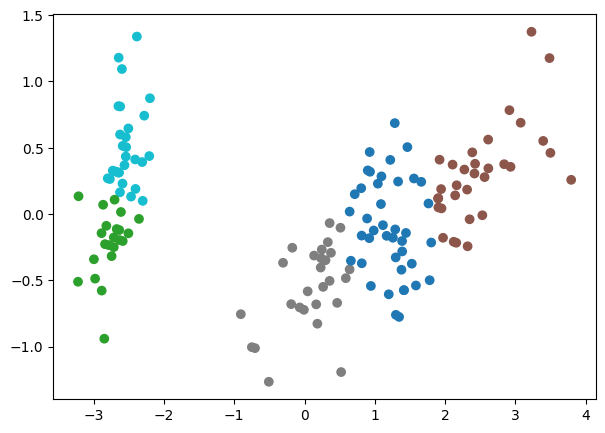

In [378]:
plt.figure(figsize=(7,5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=centroid_map,
    cmap="tab10",  
)
plt.show()